In [ ]:
#import required packages
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


In [ ]:
#load dataset

df = pd.read_excel("complaint categories dataset.xlsx", sheet_name=0)
print(df.head())
print(df.columns.tolist())


   Complaint ID                                            Comment  \
0             1  "Told three business days delivery. Not delive...   
1             2  "Return had been received but not processed an...   
2             3  "Avoid customer service. Amazon bot lets you c...   
3             4  "Says that parcel was delivered to resident bu...   
4             5  "Never dealt with such a apalling customer ser...   

              Issue  
0          delivery  
1   payment/billing  
2  customer service  
3          delivery  
4  customer service  
['Complaint ID', 'Comment', 'Issue']


In [ ]:
#clean labels & normalise categories
#normalize casing, trim whitespace, fix obvious typos
df["Issue"] = (
    df["Issue"].astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "payment/billing": "payment/billing",
        "customer service": "customer service",
        "product quality": "product quality",
        "delivery": "delivery",
        "technical website/app": "technical website/app",
    })
)


In [ ]:
#convert text labels to numeric labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Issue_id"] = le.fit_transform(df["Issue"]) #sorts alphabetically & assigns integers
label_map = dict(zip(le.classes_, le.transform(le.classes_))) #dictionary showing mapping
print("Issue map:", label_map)


Issue map: {'customer service': np.int64(0), 'delivery': np.int64(1), 'payment/billing': np.int64(2), 'product quality': np.int64(3), 'technical website/app': np.int64(4)}


In [ ]:
#text normalisation & cleaning
#reduce words to ther root
def clean_text(s):
    s = str(s).lower().strip() #lowercase
    s = s.strip('"').strip("'") #remove stray quotes
    s = re.sub(r"\s+", " ", s) #normalize whitespace
    s = re.sub(r"[^\w\s/']", " ", s)  #remove non‑alphanumeric except apostrophes and slashes
    return s.strip()

df["text"] = df["Comment"].astype(str).apply(clean_text)


In [ ]:
#handle common typos
corrections = {
    "noone": "no one",
    "neve": "never",
    "evem": "even",
    "aamazon": "amazon",
    "apalling": "appalling",
    "euphamisms": "euphemisms",
    "wwith": "with",
    "bacl": "back",
    "ebing": "being",
    "policay": "policy",
    "regster": "register",
    "acount": "account",
}
def fix_typos(s):
    for k, v in corrections.items():
        s = s.replace(k, v)
    return s
df["text"] = df["text"].apply(fix_typos)


Class distribution:

Issue
delivery                 40
payment/billing          40
customer service         40
product quality          40
technical website/app    40
Name: count, dtype: int64


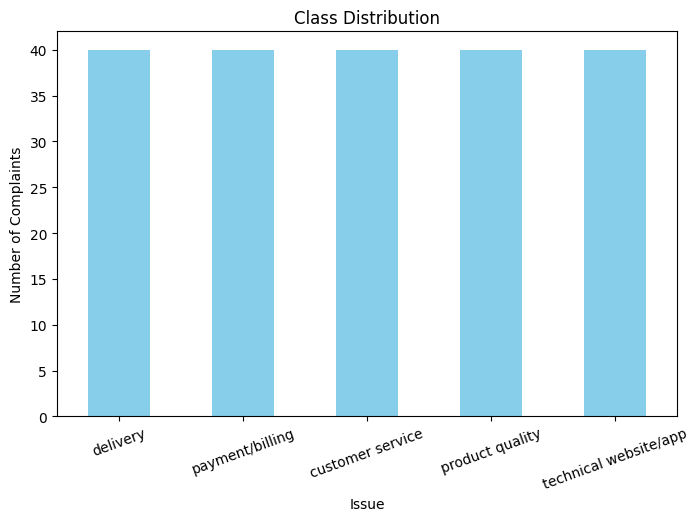

In [ ]:
#check class distribution
class_counts = df["Issue"].value_counts()

print("Class distribution:\n")
print(class_counts)


In [ ]:
#train/test split with classification

X = df["text"]
y = df["Issue"] #use string labels for reports

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
#TF-IDF vectorization
#limit features to avoid overfitting, keep English stopwords
#words that are important and meaningful get higher weights

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=5000,
    min_df=1
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [ ]:
#save artifacts for reuse
import joblib
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")
joblib.dump(le, "label_encoder.joblib")  #if you used LabelEncoder


['label_encoder.joblib']

In [ ]:
#machine learning models
#with imbalance handling
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Linear SVM": LinearSVC(class_weight="balanced"),
    "Naive Bayes": MultinomialNB()  # NB does not support class_weight
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model


In [ ]:
#evaluation metrics
#precision, recall, F1
#confusion matrix
#accuracy for comparison
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_tfidf)

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {"accuracy": acc, "confusion_matrix": cm}



===== Logistic Regression =====
                       precision    recall  f1-score   support

     customer service       0.75      0.75      0.75         8
             delivery       1.00      1.00      1.00         8
      payment/billing       0.80      0.50      0.62         8
      product quality       0.78      0.88      0.82         8
technical website/app       0.70      0.88      0.78         8

             accuracy                           0.80        40
            macro avg       0.81      0.80      0.79        40
         weighted avg       0.81      0.80      0.79        40


===== Linear SVM =====
                       precision    recall  f1-score   support

     customer service       0.67      0.75      0.71         8
             delivery       1.00      1.00      1.00         8
      payment/billing       0.80      0.50      0.62         8
      product quality       0.78      0.88      0.82         8
technical website/app       0.78      0.88      0.82     

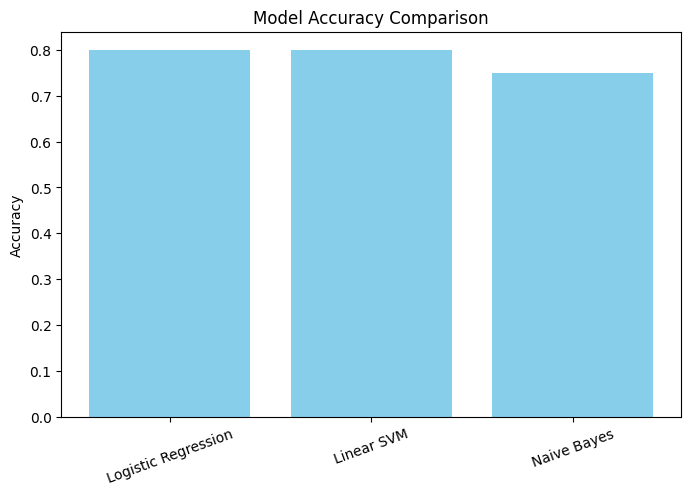

In [ ]:
#accuracy comparison
#bar chart
plt.figure(figsize=(8,5))
plt.bar(results.keys(), [r["accuracy"] for r in results.values()], color="skyblue")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()


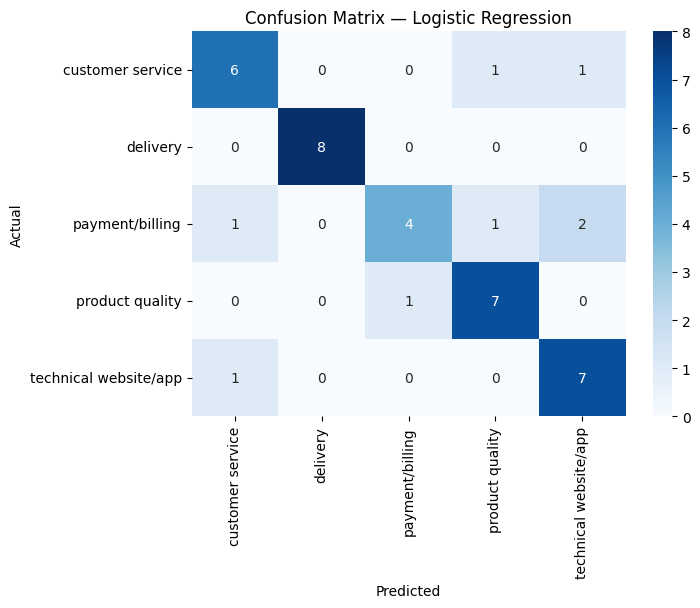

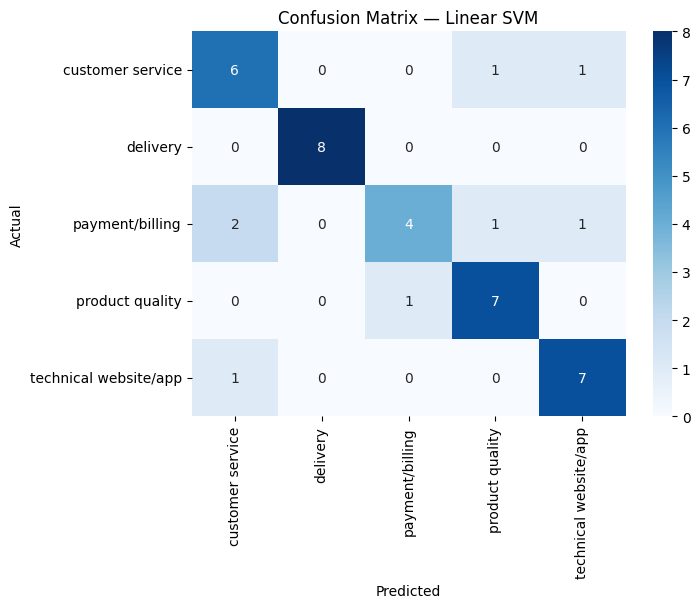

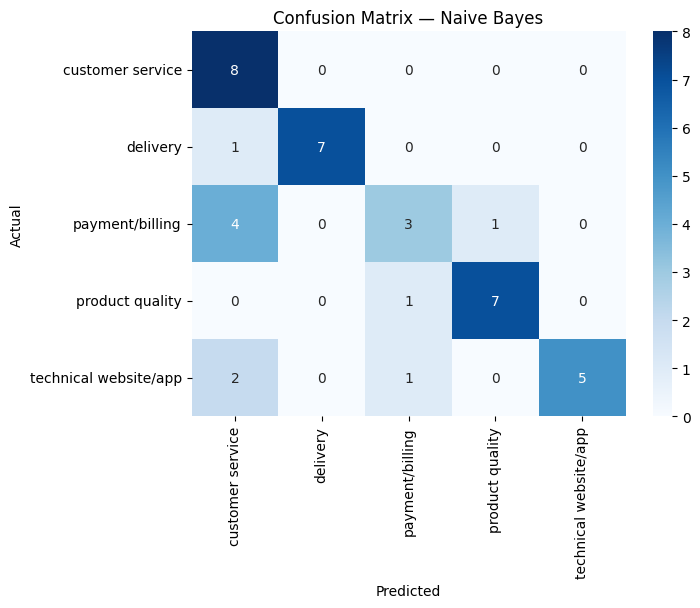

In [ ]:
#confusion matrix heatmap
for name, r in results.items():
    plt.figure(figsize=(7,5))
    sns.heatmap(
        r["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=sorted(y.unique()),
        yticklabels=sorted(y.unique())
    )
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [ ]:
#prediction function
#defaults to logistic regression
#clean, vectorize, predict
def predict_issue(text, model=trained_models["Logistic Regression"]):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    return model.predict(vec)[0]

#example
print(predict_issue("My refund still hasn't been processed after two weeks"))


payment/billing


In [ ]:
#export/save the model
joblib.dump(model, "complaint_classifier_logreg.joblib")


['complaint_classifier_logreg.joblib']